In [27]:
##importing libraries
import nibabel as nib
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from dipy.segment.mask import median_otsu
from torch.utils.data import Dataset, DataLoader
from matplotlib import pyplot as plt
import matplotlib.pyplot as plt
from copy import deepcopy
import time

In [2]:
# #Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

Training on: cpu


In [3]:
##pytorch details
!pip show torch

/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/bin/pip: line 2: /Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_cvae/cvae/bin/python3: No such file or directory
/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/cvae/bin/pip: line 2: exec: /Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_cvae/cvae/bin/python3: cannot execute: No such file or directory


In [4]:
# ##Checking torch version, cuda, GPU and memory 
# print(torch.__version__)              # Should show +cu128 (not +cpu)
# print(torch.cuda.is_available())      # Should be True
# print(torch.cuda.get_device_name(0))  # Should show "NVIDIA GeForce GTX 1650 Ti"
# print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

In [5]:
##Processors
import subprocess
try:
    result = subprocess.run(
        ["nvidia-smi"],
        capture_output=True,
        text=True,
        check=True
    )
    print(result.stdout)
except FileNotFoundError:
    print("nvidia-smi is not installed or not on PATH.")
except subprocess.CalledProcessError as exc:
    print("nvidia-smi failed:", exc.stderr or exc)

nvidia-smi is not installed or not on PATH.


## **DATASET**

In [6]:
##loding data
path = "/Users/sarojrai/Desktop/LSBU/Dissertation /IVIM_Autoencoder/notebooks/BRAIN"

raw_data=nib.load(path+"/data.nii.gz")
mri_data=raw_data.get_fdata()
print(mri_data.shape)

(256, 256, 54, 21)


## **Data description**
1. H: Height of one image in the sequence
2. W: Width of one image in the sequence
3. D: Depth of images or Number of images in the sequence
4. C: Number of channels (like 3 RGB or b-values)

In [7]:
# data = torch.randn(2,3,4,4)
# data.shape
# data[0]
# plt.imshow(data[0])

In [8]:
# Load b-values from the file
with open(path+"/bvalues.bval", "r") as f:
    bvals_str = f.read().split()
bvals_arr = np.array([float(b) for b in bvals_str], dtype=np.float32)

print(f"Loaded b-values: {bvals_arr}")
print(f"Number of b-values (N_b): {len(bvals_arr)}")

Loaded b-values: [   0.   10.   20.   30.   40.   60.   80.  100.  120.  140.  160.  180.
  200.  300.  400.  500.  600.  700.  800.  900. 1000.]
Number of b-values (N_b): 21


In [9]:
bvals_arr

array([   0.,   10.,   20.,   30.,   40.,   60.,   80.,  100.,  120.,
        140.,  160.,  180.,  200.,  300.,  400.,  500.,  600.,  700.,
        800.,  900., 1000.], dtype=float32)

## **DATA PREPROCESSING FOR SIMILAR NEIGHBOURING PIXELS EXTRACTION**

In [10]:
#Get raw dimensions
H, W, D, b_value = mri_data.shape 

#Calculate indices for a 70/15/15 split
train_end = int(D * 0.70)
val_end = int(D * 0.85)  # 70% + 15% = 85%

#Slice Raw MRI Data (Along Axis 2 / Depth)
raw_train_data = mri_data[:, :, :train_end, :]
raw_val_data   = mri_data[:, :, train_end:val_end, :]
raw_test_data  = mri_data[:, :, val_end:, :]

In [ ]:
##displaying the 2 slice of mri data over 21 b-value
fig, ax = plt.subplots(3,7, figsize=(10,6))

# Flatten the 2D array of axes into a 1D array for easier iteration
flat_axes = ax.ravel()

plot_counter = 0
# Iterate over the first two slices (depth dimension) of the MRI data
for i in range(raw_train_data[:,:,:2,:].shape[2]):
  # Iterate over all b-values
  for j in range(raw_train_data.shape[3]): # j will be 0 to 20 b-values
    if plot_counter < len(flat_axes): # Check if there are still subplots available
      current_ax = flat_axes[plot_counter]
      current_ax.imshow(raw_train_data[:,:,i,j], cmap='gray')
      current_ax.set_title(f"Slice {i}, b={j}") # Add a title for context
      current_ax.axis('off') # Turn off axis labels for cleaner display
      plot_counter += 1

plt.tight_layout() # Adjust subplot parameters for a tight layout
plt.show()

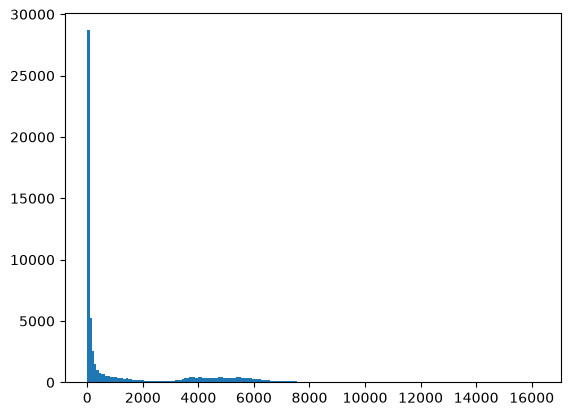

In [11]:
img = raw_train_data[:,:,20,0]
#for standardize the pixel values
# mean = np.mean(img)
# std = np.std(img)
# img = img-mean
# img = img/std
plt.hist(img.flatten(),bins=200)
plt.show()


In [12]:
#Slice axis 3 (b-value) at index 0, keeping all H, W, and D
b0_raw = mri_data[:, :, :, 0]  #(256, 256, 54) -> (H, W, D)

# Generate the mask using the correct 3D spatial volume
_, otsu_mask = median_otsu(b0_raw, median_radius=3, numpass=2)
brain_msk = otsu_mask.astype(np.uint8)   # (256, 256, 54) -> (H, W, D)

#Correct spatial dimension
print("Mask shape (H, W, D):", brain_msk.shape)  #(256, 256, 54)


Mask shape (H, W, D): (256, 256, 54)


In [13]:
#Slice Brain Masks to Match
train_mask = brain_msk[:, :, :train_end]
val_mask   = brain_msk[:, :, train_end:val_end]
test_mask  = brain_msk[:, :, val_end:]

print(f'shape of train: {train_mask.shape}')
print(f'shape of val: {val_mask.shape}')
print(f'shape of test: {test_mask.shape}')

shape of train: (256, 256, 37)
shape of val: (256, 256, 8)
shape of test: (256, 256, 9)


In [14]:
##process in the chunk to speed up
def process_chunk(padded_px, padded_b0, y, x, dy, dx,
                    center_flat_idx, target_slots, b_value):
    """
    Broadcasting Technique:
      Vectorized core, run on one chunk of pixels at a time so peak memory
    stays bounded regardless of total voxel count N.
    """

    n = len(y)

    ##Broadcasting technique to speed up the calculation
    #Build 5x5 neighborhood (25 positions per pixel) fetch using 5x5 window
    yy = y[:, None] + dy[None, :]
    xx = x[:, None] + dx[None, :]

    ##similar neighbouring pixels calculation
    b0_neighbors = padded_b0[yy, xx]              # (n, 25)
    center_b0 = padded_b0[y, x]                     # (n,)
    similarity = np.abs(center_b0[:, None] - b0_neighbors)  # (n, 25)

    ##a masking array of 25 boolean coordinate
    ##removing center coordinate from the extracted 5x5 similarity matrix
    keep = np.ones(25, dtype=bool)
    keep[center_flat_idx] = False

    ##indexing drops/remove center from the column where keep==false
    # Drops the center coordinates
    similarity = similarity[:, keep] # (n, 24)
    yy, xx = yy[:, keep], xx[:, keep]

    #sort the python list.sort() 
    #order indices says which column to pick per row  
    order = np.argsort(similarity, axis=1, kind='stable')  # (n, 24)
    top8_indices = order[:, :8]

    ##select values from an array along a specified axis using index arrays
    yy_top = np.take_along_axis(yy, top8_indices, axis=1)      # (n, 8)
    xx_top = np.take_along_axis(xx, top8_indices, axis=1)
    full_top8 = padded_px[:, yy_top, xx_top]  # (b_value, n, 8)

    ##initialize the 3x3 patch of most similar pixels
    block = np.zeros((n, 3, 3, b_value), dtype=np.float32)
    center_vals = padded_px[:, y, x]             # (b_value, n)
    block[:, 1, 1, :] = center_vals.T

    vals = np.transpose(full_top8, (1, 2, 0))           # (n, 8, b_value)
    block[:, target_slots[:, 0], target_slots[:, 1], :] = vals

    return block


##extracting the similar neighbouring pixels patches 
def similar_neighborhood_patch(data, brain_masker, chunk_size=2000):
    H, W, D, b_value = data.shape

    y_factor = 2.0 / (H - 1) if H > 1 else 1.0
    x_factor = 2.0 / (W - 1) if W > 1 else 1.0

    similar_patch, center_coord, norm_cent_coord  = [], [], []

    #Looping over each slices
    for i in range(D):
      slices_data = data[:, :, i, :]

      mri_slice = np.transpose(slices_data, (2, 0, 1))  # (b, H, W)
      
      #brain mask slicing (no transpose needed for 2D)
      brain_mask_slice = brain_masker[:, :, i]  # (H, W)

      ##Intensity normalization
      b0_original = mri_slice[0].copy()
      ##select only valid pixels
      b0_valid_px = np.where(b0_original==0, 1e-8, b0_original)
      ##normalize
      mri_slice_norm = mri_slice/b0_valid_px[None:, :]

      #Threshold
      #Finds the actual intensity mean of the b=0 brain pixels, not mask density
      b0_image = mri_slice[0]
      b0_img_mean = np.mean(b0_image[brain_mask_slice > 0]) if np.any(brain_mask_slice > 0) else 0
      b0_threshold = 0.50 * b0_img_mean

      # Find indices based on corrected 2D mask and threshold
      brain_indices = np.argwhere((brain_mask_slice > 0) & (b0_image >= b0_threshold))
      N = len(brain_indices)
      print(f"Slice {i:02d}/{D-1}: Processing {N} brain pixels to build 2D similarity blocks")

      ##if number of voxels is zero continue calculation
      if N == 0:
          continue
      
      ##padding tensors
      ##padded signal at b-value=0
      padded_px = np.pad(mri_slice_norm, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
      padded_b0 = np.pad(b0_original, ((2, 2), (2, 2)), mode='constant', constant_values=0)


      ##x and y coordinates of brain indices with padding
      y_all = (brain_indices[:, 0] + 2).astype(np.int32)
      x_all = (brain_indices[:, 1] + 2).astype(np.int32)

      ##array ranging from -2 to 3, for generating a 5x5 window: array([-2, -1,  0,  1,  2])
      ##5x5 window matrix
      ##flatten them in 1d array
      ##offset coordinate index for central pixel
      offs = np.arange(-2, 3, dtype=np.int32)
      dy, dx = np.meshgrid(offs, offs, indexing='ij')
      dy, dx = dy.ravel(), dx.ravel()
      center_flat_idx = 12  #(0,0) offset's position in the flatten 25-length grid

      ##initialize the empty neighbors slot to store top neighbor pixels later in calculation
      top_neighbors_slot = np.array([
          (a, b) for a in range(3) for b in range(3) if not (a == 1 and b == 1)
          ])

      ##initialize the empty similar neighbourhood block array
      similar_neig_block = np.zeros((N, 3, 3, b_value), dtype=np.float32)

      ##actual similar neighbourhood data calculated in chunks and store in pre-defined similar_neig_block
      for start in range(0, N, chunk_size):
          end = min(start + chunk_size, N)
          similar_neig_block[start:end] = process_chunk(padded_px, padded_b0, y_all[start:end], x_all[start:end],
                                                    dy, dx, center_flat_idx, top_neighbors_slot, b_value)

      center_coords = list(map(tuple, brain_indices))
      y0 = brain_indices[:, 0] * y_factor - 1.0
      x0 = brain_indices[:, 1] * x_factor - 1.0
      center_norm_coord = list(zip(y0.tolist(), x0.tolist()))

      similar_patch.append(similar_neig_block)
      center_coord.append(center_coords)
      norm_cent_coord.append(center_norm_coord)
      
    print("Processing completed.")
    return similar_patch, center_coord, norm_cent_coord


In [15]:
# import numpy as np
# b0 = np.arange(16).reshape(4,4)           # original 2D
# padded_b0 = np.pad(b0, ((2,2),(2,2)), mode='constant')  # (8,8)
# y = np.array([2,3])                       # padded coords
# x = np.array([2,3])
# print(padded_b0[y, x])                    # [ 0  5]  (n,) OK
# yy = y[:,None] + np.array([-1,0,1])       # (2,3)
# xx = x[:,None] + np.array([-1,0,1])
# print(padded_b0[yy, xx].shape)            # (2,3) OK

In [16]:
# ##extracting the similar neighbouring pixels patches 
# def similar_neighborhood_patch(data, brain_masker, chunk_size=2000):
#     H, W, D, b_value = data.shape

#     y_factor = 2.0 / (H - 1) if H > 1 else 1.0
#     x_factor = 2.0 / (W - 1) if W > 1 else 1.0

#     similar_patch, center_coord, norm_cent_coord  = [], [], []

#     #Looping over each slices
#     for i in range(D):
#       slices_data = data[:, :, i, :]

#       mri_slice = np.transpose(slices_data, (2, 0, 1))  # (b, H, W)
      
#       #brain mask slicing (no transpose needed for 2D)
#       brain_mask_slice = brain_masker[:, :, i]  # (H, W)

#       #Threshold
#       #Finds the actual intensity mean of the b=0 brain pixels, not mask density
#       b0_image = mri_slice[0]
#       b0_img_mean = np.mean(b0_image[brain_mask_slice > 0]) if np.any(brain_mask_slice > 0) else 0
#       b0_threshold = 0.50 * b0_img_mean

#       # Find indices based on corrected 2D mask and threshold
#       brain_indices = np.argwhere((brain_mask_slice > 0) & (b0_image >= b0_threshold))
#       N = len(brain_indices)
#       print(f"Slice {i}/{D-1}: Processing {N} brain pixels to build 2D similarity blocks")

#       ##if number of voxels is zero continue calculation
#       if N == 0:
#           continue
      
#       ##padding tensors
#       ##padded signal at b-value=0
#       padded_px = np.pad(mri_slice, ((0, 0), (2, 2), (2, 2)), mode='constant', constant_values=0)
#       padded_b0 = padded_px[0]


#       ##x and y coordinates of brain indices with padding
#       y_all = (brain_indices[:, 0] + 2).astype(np.int32)
#       x_all = (brain_indices[:, 1] + 2).astype(np.int32)

#       ##array ranging from -2 to 3, for generating a 5x5 window: array([-2, -1,  0,  1,  2])
#       ##5x5 window matrix
#       ##flatten them in 1d array
#       ##offset coordinate index for central pixel
#       offs = np.arange(-2, 3, dtype=np.int32)
#       dy, dx = np.meshgrid(offs, offs, indexing='ij')
#       dy, dx = dy.ravel(), dx.ravel()
#       center_flat_idx = 12  #(0,0) offset's position in the flatten 25-length grid

#       ##initialize the empty neighbors slot to store top neighbor pixels later in calculation
#       top_neighbors_slot = np.array([
#           (a, b) for a in range(3) for b in range(3) if not (a == 1 and b == 1)
#           ])

#       ##initialize the empty similar neighbourhood block array
#       similar_neig_block = np.zeros((N, 3, 3, b_value), dtype=np.float32)

#       ##actual similar neighbourhood data calculated in chunks and store in pre-defined similar_neig_block
#       for start in range(0, N, chunk_size):
#           end = min(start + chunk_size, N)
#           similar_neig_block[start:end] = process_chunk(padded_px, padded_b0, y_all[start:end], x_all[start:end],
#                                                     dy, dx, center_flat_idx, top_neighbors_slot, b_value)

#       center_coords = list(map(tuple, brain_indices))
#       y0 = brain_indices[:, 0] * y_factor - 1.0
#       x0 = brain_indices[:, 1] * x_factor - 1.0
#       center_norm_coord = list(zip(y0.tolist(), x0.tolist()))

#       similar_patch.append(similar_neig_block)
#       center_coord.append(center_coords)
#       norm_cent_coord.append(center_norm_coord)
      
#     print("Processing completed.")
#     return similar_patch, center_coord, norm_cent_coord


In [17]:
#Run Patches extraction function independently on each chunk
print("Extracting Training Patches")
train_patches, _, train_norm_coords = similar_neighborhood_patch(raw_train_data, train_mask)

print("\nExtracting Validation Patches")
val_patches, _, val_norm_coords = similar_neighborhood_patch(raw_val_data, val_mask)

print("\nExtracting Testing Patches")
test_patches, test_coords, test_norm_coords = similar_neighborhood_patch(raw_test_data, test_mask)

#Concatenate slices into monolithic numpy arrays
X_train = np.concatenate(train_patches, axis=0)  # (N_train, 3, 3, b_value)
X_val   = np.concatenate(val_patches, axis=0)    # (N_val, 3, 3, b_value)
X_test  = np.concatenate(test_patches, axis=0)   # (N_test, 3, 3, b_value)

# Flatten the coordinate lists for conditional context
coord_train = np.array([c for slice_c in train_norm_coords for c in slice_c], dtype=np.float32)
coord_val   = np.array([c for slice_c in val_norm_coords for c in slice_c], dtype=np.float32)
coord_test  = np.array([c for slice_c in test_norm_coords for c in slice_c], dtype=np.float32)


Extracting Training Patches
Slice 00/36: Processing 1100 brain pixels to build 2D similarity blocks
Slice 01/36: Processing 1311 brain pixels to build 2D similarity blocks
Slice 02/36: Processing 1669 brain pixels to build 2D similarity blocks
Slice 03/36: Processing 2411 brain pixels to build 2D similarity blocks
Slice 04/36: Processing 3326 brain pixels to build 2D similarity blocks
Slice 05/36: Processing 4100 brain pixels to build 2D similarity blocks
Slice 06/36: Processing 4728 brain pixels to build 2D similarity blocks
Slice 07/36: Processing 5202 brain pixels to build 2D similarity blocks
Slice 08/36: Processing 5564 brain pixels to build 2D similarity blocks
Slice 09/36: Processing 5959 brain pixels to build 2D similarity blocks
Slice 10/36: Processing 6853 brain pixels to build 2D similarity blocks
Slice 11/36: Processing 8110 brain pixels to build 2D similarity blocks
Slice 12/36: Processing 9335 brain pixels to build 2D similarity blocks
Slice 13/36: Processing 10477 brain 

In [18]:
X_train[0]

array([[[1.        , 0.7744465 , 0.8072117 , 0.82781136, 0.7441167 ,
         0.69936264, 0.74761045, 0.5867344 , 0.60328937, 0.53246814,
         0.5386402 , 0.4151038 , 0.44574443, 0.31591532, 0.22135457,
         0.20950624, 0.18000263, 0.1953747 , 0.13910598, 0.15617156,
         0.09742675],
        [1.        , 0.5533619 , 0.32959533, 0.74360824, 0.4694777 ,
         0.47384518, 0.1972078 , 0.14794442, 0.35720235, 0.34725583,
         0.30239362, 0.28878242, 0.22946423, 0.1247082 , 0.14151078,
         0.1005993 , 0.11296628, 0.09627642, 0.12547806, 0.11951357,
         0.10411981],
        [1.        , 0.6769471 , 0.4590843 , 0.92023176, 0.5630377 ,
         0.7006244 , 0.526972  , 0.37602347, 0.6541385 , 0.5708311 ,
         0.4515527 , 0.44367996, 0.28467622, 0.2368071 , 0.1921778 ,
         0.16893184, 0.1782051 , 0.12974456, 0.13714117, 0.1039773 ,
         0.12513176]],

       [[1.        , 0.65984577, 0.670416  , 0.6672307 , 0.64407486,
         0.62850356, 0.5571481 , 0.

In [19]:
# ##display 3x3 block
# plt.imshow(X_train[0][0,:,:,0], cmap='gray') # Display the signal at 21 b-value of the first block's middle depth slice
# plt.show()

# X_train[0] ##shape=(119110, 3, 3, 21)

# x=torch.from_numpy(X_train[0]).float()
# x.shape


# ##shape=(119110, 3, 3, 21) -----> shape=(119110, 21, 3, 3) ----> Idx shape=(0, 3, 1, 2)
# x1=x.permute(2, 0, 1) 
# x1.shape


# print(x1[:,0:1, :, : ])
# x1[:, 0:1, :, : ].shape ##torch.Size([21, 3, 3])


# x1[:,0:1,:,:][0].shape

# ##b0_image
# plt.imshow(x1[:, 0:1, :, :][0], cmap='gray')
# plt.show()


# # Visualise the highest b-value (e.g., index -1), with non-zero b-value
# plt.imshow(x1[0, -1, :, :], cmap="gray", vmin=0, vmax=1)
# plt.colorbar()
# plt.show()

In [20]:
##A custom data creator function
class DiffusionDataset(Dataset):
    def __init__(self, similar_patches, condition):
        """
        similar_patches: NumPy array of shape (N, 3, 3, b_values)
        condition (list of coordinates): NumPy array of shape (N, 2) 
        """
        # data is a list of slices, concatenate it into a monolithic array 
        # inside (__init__) to protect from list indexing bugs
        ##checking whether it is a list or array
        if isinstance(similar_patches, list):
            self.patches = np.concatenate(similar_patches, axis=0)
        else:
            self.patches = similar_patches

        # Convert the entire condition dataset to a PyTorch tensor at initialization. 
        # This avoids slow memory re-allocations in __getitem__
        self.condition = torch.tensor(np.array(condition), dtype=torch.float32)

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        #convert the individual patch array to a tensor
        x = torch.from_numpy(self.patches[idx]).float()

        # checking dimension for reshaping
        if x.dim() == 3:
            x = x.permute(2, 0, 1)      #(3, 3, b_values) -> (b_values, 3, 3)
        elif x.dim() == 4:
            x = x.permute(0, 3, 1, 2)   #(N, 3, 3, b_values) -> (N, b_values, 3, 3)
        else:
            raise ValueError(f"Unexpected tensor shape {tuple(x.shape)}")

        # Clean, fast index fetch for the condition vector
        y = self.condition[idx]
        return x, y



In [21]:
#INSTANTIATE THE TORCH DATALOADERS
# Voxel-wise/Patch regression networks process data fast. A large batch size 
# improves training speed and stabilizes the CVAE latent space optimization.
BATCH_SIZE = 128  

train_dataset = DiffusionDataset(X_train, coord_train)
val_dataset   = DiffusionDataset(X_val, coord_val)
test_dataset  = DiffusionDataset(X_test, coord_test)

# Training, Validation and Testing data loaders
#Shuffle=True is strictly applied only to training data
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)


print(f"Data Loaders successfully created:")
print(f"Train Batches:      {len(train_loader)} (Total patches: {len(train_dataset)})")
print(f"Validation Batches: {len(val_loader)} (Total patches: {len(val_dataset)})")
print(f"Testing Batches:    {len(test_loader)} (Total patches: {len(test_dataset)})")



Data Loaders successfully created:
Train Batches:      3790 (Total patches: 485126)
Validation Batches: 1073 (Total patches: 137341)
Testing Batches:    662 (Total patches: 84705)


In [22]:
# Fetch one test batch and check
for train_x, train_coord in train_loader:
    print(f"Batch X Shape (Expects [4, b_values, 3, 3]): {train_x.shape}")
    print(f"Batch Y Shape (Expects [4, 2]):           {train_coord.shape}")
    print(f"X_train values: {train_x[0,:,:,:]}")
    break


Batch X Shape (Expects [4, b_values, 3, 3]): torch.Size([128, 21, 3, 3])
Batch Y Shape (Expects [4, 2]):           torch.Size([128, 2])
X_train values: tensor([[[1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000]],

        [[0.9834, 1.0070, 0.9721],
         [0.9633, 0.9675, 1.0069],
         [0.9642, 0.9743, 0.9938]],

        [[0.9528, 0.9581, 0.9541],
         [0.9484, 0.9496, 0.9663],
         [0.9509, 0.9602, 0.9538]],

        [[0.9518, 0.9512, 0.9578],
         [0.9361, 0.9353, 0.9842],
         [0.9501, 0.9624, 0.9266]],

        [[0.9213, 0.9435, 0.9541],
         [0.9234, 0.9129, 0.9590],
         [0.9502, 0.9342, 0.9405]],

        [[0.9029, 0.9154, 0.9367],
         [0.9200, 0.9052, 0.9273],
         [0.9253, 0.9198, 0.9233]],

        [[0.9116, 0.9290, 0.9377],
         [0.9060, 0.8973, 0.9509],
         [0.9331, 0.9104, 0.9182]],

        [[0.8736, 0.9020, 0.9082],
         [0.8757, 0.8647, 0.9000],
         [0.8850, 0.8808, 0.9

## **PHYSIOLOGICAL BI-EXPONENTIAL SIGNAL EQUATION**

In [23]:
##Physics IVIM signal function
def ivim_biex_signal(theta, b_vals):
    ##IVIM parameters
    D = theta[:, 0:1]
    Ds = theta[:, 1:2]
    f = theta[:, 2:3]

    #b values broadcastable if b-value is 1D array
    if b_vals.dim()<=2:
        b = b_vals.view(1,-1, 1, 1)
    else:
        b = b_vals.reshape(1, -1, 1, 1)
    
    ##perfusion signal due to the flow of blood
    s_perf = f*torch.exp(-b * Ds)
    ##True diffusion signal due to water molecules in tissues
    s_diff = (1-f)*torch.exp(-b*D)
    ##bi-exponential signal
    s_sum = s_perf + s_diff
    return s_sum, s_perf, s_diff

## **MODEL ARCHITECTURE**

In [24]:
##Epoch
EPOCHS = 1
INPUT_CHANNEL = len(bvals_arr)
LATENT_DIM = 64
COORD_DIM = 2
LEARNING_RATE = 0.001
KL_TAR = 0.01
PARAM_WEIGHT = 0.1
WARMUP_EPS = 10
ANNEAL_EPS = 30

## **UNCERTAINTY QUANTIFICATION WHILE ESTIMATING PARAMETERS**

In [25]:
##MonteCarlo Dropout
class MCDropout(nn.Module):
    """"
    1D dropout layer which enforces the dropout layer to stay active even in
    model evaluation called inference.
    """
    def __init__(self, p:float):
        super().__init__()
        self.p = p
        self.mc_active = True ##by default is always on

    def forward(self, input: torch.Tensor):
        use_dropout = self.mc_active or self.training
        return F.dropout(input, p=self.p, training=use_dropout)

In [26]:
##Physics informed IVIM cVAE
class PhysicsCVAE(nn.Module):
    """
    Physics-Informed Conditional Variational Autoencoder (PIcVAE) for IVIM parameter estimation.

    Architecture
    -----------
    Encoder: 2D CNN on 3x3 multi-b-value patches  (coordinate-FREE)
    Decoder: z + normalised spatial coords  →  IVIM bi-exponential forward model
    """
    def __init__(self, 
                 in_channel:int, 
                 bvalues: torch.Tensor, 
                 latent_dim:int, 
                 coord_dim=2, 
                 bvals=None, 
                 dropout_p=0.10):
        """
        PARAMETERS:
        ----------
        in_channel  : int   Number of b-values (= input channels).
        bvalues     : Tensor 1-D tensor of b-values (s/mm²).
        latent_dim  : int   Dimensionality of latent vector z.
        coord_dim   : int   Spatial coordinate dimensions (default 2 for x, y).
        dropout_p   : float MC-Dropout probability in decoder.
        """
        super().__init__()
        self.latent_dim = latent_dim
        self.coord_dim = coord_dim

        ##registering b-values as buffer parameters
        self.register_buffer("bvalues", bvalues.view(1, -1, 1, 1)) 

        ##ENCODER NET
        # Input:  (B, in_channel, 3, 3)
        # Output: (B, 576)   [64 channels x 3 x 3, flattened]

        self.encoder_net = nn.Sequential(
            ##first conv layer
            nn.Conv2d(in_channel, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.Conv2d(256, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            MCDropout(0.15),
            nn.Flatten()
        )

        ## 64 CNN output channel, 3-Height, 3-Width 
        ##encoder output
        encoder_output_dim = 64*3*3


        ##mean and variance for latent space
        self.fc_mu = nn.Linear(encoder_output_dim, latent_dim)
        self.fc_logvar = nn.Linear(encoder_output_dim, latent_dim)

        ##DECODER NET: conditioned on normalized spatial coordinates
        ##conditional vector layer
        self.de_coord_layer = nn.Sequential(
            nn.Linear(self.coord_dim, 8),
            nn.ReLU()
        )

        ##combined 
        combined_decoder_size = self.latent_dim+8

        self.decoder_net = nn.Sequential(
            nn.Linear(combined_decoder_size, 128), 
            nn.ReLU(),
            MCDropout(dropout_p),
            nn.Linear(128, 3*3*3) ##3 parameters x 3x3 pixels = 27
        )
        
    # Physical parameter constraints
    @staticmethod
    def physics_constraint(raw_params):
        """
        Split (B, 27) → 3 param maps with physical constraints.
        Returns: theta (B, 3, 3, 3) stacked as [D, D*, f]
                Individual: D (B,1,3,3), Ds (B,1,3,3), f (B,1,3,3)
        """
        ## Physiological Constant ranges
        D_MIN,  D_MAX   = 0.0001, 0.004 #Water restriction boundaries
        Ds_MIN, Ds_MAX  = 0.005, 0.020 #High-velocity capillary perfusion micro-circulation
        f_MIN,  f_MAX   = 0.000, 0.300 #Capillary plasma fraction cap (50%)

        ##splitting 27 raw outputs into 3 groups of 9 having shape (B, 1, 3, 3)
        d_chunk, ds_chunk, f_chunk = torch.chunk(raw_params, chunks=3, dim=1)

        #Reshape to 2D spatial patches: Each becomes (B, 1, 3, 3)
        d_raw = d_chunk.view(-1, 1, 3, 3)
        ds_raw = ds_chunk.view(-1, 1, 3, 3)
        f_raw = f_chunk.view(-1, 1, 3, 3)

        ##IVIM THREE PARAMETERS
        ##True diffusion
        # Shifted softplus: phi(x) = ln(1+e^x) - ln(2)  ->  output in [0, inf)
        # At x = 0: phi(0) = 0  (standard softplus gives ln(2) ~ 0.693 here)
        zero_tensor = torch.zeros_like(d_raw)
        t_D = torch.clamp(F.softplus(d_raw)-F.softplus(zero_tensor), max=1.0)

        ##Perfusion - pseudo-diffusion
        p_D = torch.clamp(F.softplus(ds_raw)-F.softplus(zero_tensor), max=1.0)

        ##perfusion fraction: Perfusion fraction remains a standard native sigmoid percentage 
        p_f = torch.sigmoid(f_raw)

        ##Scaling the three parameters using biophysiological constants 
        D  = D_MIN + t_D*(D_MAX - D_MIN)
        Ds = Ds_MIN + p_D*(Ds_MAX - Ds_MIN)
        f  = f_MIN + p_f*(f_MAX - f_MIN)

        ##Stacking parameters safely back into the (B, 3, 3, 3) shape
        theta_params = torch.cat([D, Ds, f], dim=1)

        return D, Ds, f, theta_params

    ## CVAE methods
    ##ENCODER
    def Encode(self, x_similar_patch:torch.Tensor):
        """Encoder: multi-b-value patch -> (mu, logvar). No coord conditioning."""
        image_vector = self.encoder_net(x_similar_patch) #image feature maps with shape (B, 576) 
        mu = self.fc_mu(image_vector)  
        logvar = self.fc_logvar(image_vector)
        return mu, logvar

    ##LATENT SPACE
    ##Appying reparameterization trick 
    #way to sample the latent variable(z) from the distribution of N(mu, variance)
    def reparameterize(self, mu, logvar):
        """Standard VAE reparameterisation trick: z = mu + sigma * epsilon."""
        ##standard deviation from log-variance
        std = torch.exp(0.5 * logvar) 
        ##epsilon is a noise variable with randomness on it
        eps = torch.randn_like(std) 
        ##reparameterized sample
        z = mu + eps*std
        return z
    
    ##DECODER
    def Decode(self, z_sample:torch.Tensor, coord:torch.Tensor):
        """
        Decoder: latent(z) + spatial coords - IVIM bi-exponential signal

        Parameters:
        ----------
        z     : (B, latent_dim)   sampled latent vector
        coord : (B, 2)            normalised spatial coordinates

        Returns
        -------
        s_total    : (B, C_bvals, 3, 3)  reconstructed signal
        components : tuple(s_total, s_perf, s_diff)
        IVIM parameters : tuple(theta, D, Ds, f)
        """
        ##transform the coordinates into vector form in shape (B, coord)
        coord_vec = self.de_coord_layer(coord) ##(B, 8)
        ##coordinate vectors and z-samples combine together again
        de_input = torch.cat([z_sample, coord_vec], dim=1) ##(B, latent_dim+2)
        ##decoder layer generates the raw parameters
        raw_pars = self.decoder_net(de_input) ##(B, 27)

        ##apply physical constraint
        D, Ds, f, theta_par = self.physics_constraint(raw_pars)

        ##feeding into the external IVIM bi-exponential function
        s_total, s_perf, s_diff = ivim_biex_signal(
                                                theta=theta_par, 
                                                b_vals=self.bvalues
                                                )

        return s_total, (s_total, s_perf, s_diff), (theta_par, D, Ds, f)

    ##FORWARD PASS
    def forward(self, x_inputs:torch.Tensor, c_condition:torch.Tensor):
        """ Full forward pass: encode -> reparameterise -> decode """
        ##Encoder
        mu, log_var = self.Encode(x_similar_patch=x_inputs)
        ##Reparameterization
        z = self.reparameterize(mu, log_var)
        ##Decoder
        recon, components, parameters = self.Decode(z, coord=c_condition)
        return recon, mu, log_var, components, parameters

    # MC Dropout control — toggle for training vs validation vs UQ
    def mc_dropout_set(self, active: bool):
        """Enable/disable MC mode for all MCDropout layers.

        Parameters
        ----------
        active : bool
            True  -> dropout always ON  (for MC uncertainty estimation)
            False -> dropout follows normal train/eval (for deterministic val)
        """
        for module in self.modules():
            if isinstance(module, MCDropout):
                module.mc_active = active

    #RECONSTRUCTION LOSS WITH KL-DIVERGENCE
    ##SUM is change into mean for reconstruction
    def cvae_loss(self, recons, x, mu, logvar, params=None, kl_weight=1.0, param_reg_weight=0.01):
        # Critical check for broken data feeds
        x = torch.nan_to_num(x, nan=0.0)
        recons = torch.nan_to_num(recons, nan=0.0)

        #Reconstruction Loss
        recon_loss = F.mse_loss(recons, x, reduction='mean')

        #KL Divergence (Stabilized logvar constraints)
        # Clamp logvar to prevent extreme values from causing inf/nan during logvar.exp()
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        kl_loss = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

        ##Total loss
        loss = recon_loss + (kl_weight * kl_loss)

        #Physics Constraints loss
        if param_reg_weight > 0 and params is not None:
            theta, D, Ds, f = params
            
            # Only penalise when f deviates significantly from the
            # physiological prior (f_prior = 0.20).
            f_prior = 0.20
            f_too_low  = (f < 0.02).float()   # mask: 1 where f is too small
            f_too_high = (f > 0.50).float()   # mask: 1 where f is too large
            f_reg = (torch.mean((f - f_prior).pow(2) * f_too_low)  * 10.0
                   + torch.mean((f - f_prior).pow(2) * f_too_high) * 10.0)

            # Added safety margin to avoid compounding errors
            diff_reg = torch.mean(F.relu(D - Ds * 0.30 + 1e-7) ** 2)

            smooth_d_v  = torch.mean((D[:, :, 1:, :] - D[:, :, :-1, :]) ** 2)
            smooth_ds_v = torch.mean((Ds[:, :, 1:, :] - Ds[:, :, :-1, :]) ** 2)
            smooth_d_h  = torch.mean((D[:, :, :, 1:] - D[:, :, :, :-1]) ** 2)
            smooth_ds_h = torch.mean((Ds[:, :, :, 1:] - Ds[:, :, :, :-1]) ** 2)
            
            smoothness = smooth_d_v + smooth_ds_v + smooth_d_h + smooth_ds_h

            total_physics_penalty = (f_reg * 1.0) + (diff_reg * 10.0) + (smoothness * 0.1)

            loss += param_reg_weight * total_physics_penalty

        # If anything escapes as NaN, force a small valid scalar to keep training alive
        if torch.isnan(loss):
            loss = torch.tensor(1.0, requires_grad=True).to(x.device)

        return loss, recon_loss, kl_loss


**Monte Carlo (MC) Dropout** is a technique used in deep learning to improve model predictions and estimate uncertainty by keeping dropout layers active during the testing phase.

Unlike standard dropout, which is typically disabled during inference, **MC Dropout** works as follows:

* **Maintains Dropout during Inference:** By setting the `training` parameter to `True` even for test data, the model continues to randomly deactivate neurons.
* **Performs Multiple Simulations:** Instead of a single deterministic output, the model runs several simulations ($n$ results) for each test data point.
* **Averages the Results:** Because the dropout changes the active neurons for each simulation, the model produces varying probability outputs. The final prediction is determined by calculating the **mean or average** of all these simulation results.

This approach essentially treats the network as a probabilistic model, helping to refine the final prediction by capturing variation across multiple forward passes.

The primary benefit of keeping **dropout layers active** during the testing phase is to allow the model to perform **Monte Carlo simulations**, which helps in generating a distribution of predictions rather than a single deterministic output.

Here is how this process provides value:

* **Capturing Model Uncertainty**: Because dropout randomly deactivates different sets of neurons for every forward pass, each simulation produces a slightly different probability. This variation allows you to understand the model's confidence or uncertainty regarding a specific data point.
* **Improving Accuracy**: By running multiple simulations (often referred to as $n$ results) and calculating the **mean or average** of the resulting probabilities, the model can produce a more robust and reliable prediction than standard inference.
* **Continuous Stochastic Behavior**: Setting the `training` parameter to `True` during testing ensures that the network behaves like an ensemble of multiple smaller models, which helps in better generalization and prevents the model from relying too heavily on specific neuron paths.

## **MODEL LOSS FUNCTION**

In [28]:
##computing kl weights to optimize
def compute_cyclic_kl_weight(epoch, num_epochs, kl_target, n_cycle=4, ratio=0.5):
    """
    Computes a cyclic annealing schedule for KL weights.
    
    parameters:
        epoch: Current epoch index.
        num_epochs: Total number of training epochs.
        kl_target: Maximum target value for the KL weight.
        n_cycle: Number of complete cycles across training.
        ratio: Proportion of the cycle spent increasing the weight (0.0 to 1.0).
               The remainder of the cycle keeps the weight flat at kl_target.
    """
    # Determine the number of epochs allocated to a single cycle
    period = num_epochs / n_cycle
    # Find position within the current cycle
    step = epoch % period
    
    # Calculate how many epochs in this cycle are spent scaling up
    step_up_epochs = period * ratio
    
    if step < step_up_epochs:
        # Scale up phase (linear ramp)
        progress = step / step_up_epochs
        return progress * kl_target
    else:
        # Stay phase (constant target value)
        return kl_target

##training function
def execute_cvae_training(model, train_loader, val_loader, num_epochs=EPOCHS, lr=LEARNING_RATE  , device="cuda"):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    # optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)

    ##constants 
    KL_TARGET = 1.0         
    PARAM_REG_WEIGHT = 0.05 ## 0.05    

    ##Cyclic Hyperparameter
    N_CYCLES = 4 # 100 epochs total / 4 = 25 epochs per cycle
    CYCLE_RATIO = 0.4 # 40% of cycle scaling up (10 epochs), 60% staying at target (15 epochs)

    ##Training History storage
    history = {
        "epoch":[],
        "kl weight":[],
        "train_loss":[], "train_rmse": [],
        "val_loss": [], "val_rmse": [], "val_mae":[] 
    }

    best_val_loss = float("inf")
    best_epoch = None

    print(f"Model Training Started with Cyclic Annealing...")
    print("_" * 100)

    for epoch in range(num_epochs):
        ## KL annealing for KL weights
        current_kl_weight = compute_cyclic_kl_weight(
                                                    epoch, num_epochs, 
                                                    kl_target=KL_TARGET, 
                                                    n_cycle=N_CYCLES, 
                                                    ratio=CYCLE_RATIO
                                                    )

        #TRAINING LOOP 
        model.train()

        ##training metrics
        train_loss_accum = 0.0 
        train_mse_accum = 0.0
        train_kl_accum = 0.0

        ##iterate over batches
        ## x_batch is image pixels, coord_batch is coordinates of spatial data
        for x_batch, coord_batch in train_loader:
            x_batch, coord_batch = x_batch.to(device), coord_batch.to(device)

            ##reset all gradients to zeros that is stored in the model's parameters
            optimizer.zero_grad()

            ##performing forward pass 
            recon_signals, mu, logvar, _, params = model(x_batch, coord_batch)

            ##computing loss
            loss, recon_loss, kl_loss = model.cvae_loss(
                                                        recons=recon_signals, 
                                                        x=x_batch, 
                                                        mu=mu, 
                                                        logvar=logvar,
                                                        params=params, 
                                                        kl_weight=current_kl_weight, 
                                                        param_reg_weight=PARAM_REG_WEIGHT
                                                        )

            ##weight updates: backpropagation 
            loss.backward()
            ##computes total L2 norm and clips all the gradients to prevent them from the gradient exploding problem
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            ##Updates the model's parameters using the clipped gradients
            optimizer.step()
            
            train_loss_accum += loss.item()
            train_mse_accum += recon_loss.item()
            train_kl_accum += kl_loss.item()

        n_train = len(train_loader)
        avg_train_loss = train_loss_accum / n_train
        avg_train_mse  = train_mse_accum / n_train
        avg_train_kl   = train_kl_accum / n_train
        avg_train_rmse = np.sqrt(avg_train_mse)

        #VALIDATION LOOP
        model.eval()
        model.mc_dropout_set(active=False)

        val_loss_accum = 0.0
        val_mse_accum = 0.0
        val_kl_accum = 0.0
        val_mae_accum = 0.0

        ##no weight updates required
        with torch.no_grad():
            ##looping over validation batches
            for x_val, coord_val in val_loader:
                x_val, coord_val = x_val.to(device), coord_val.to(device)

                ##forward pass on validation data
                recon_v, mu_v, logvar_v, _, params_v = model(x_val, coord_val)

                ##computing loss
                v_loss, v_recon, v_kl = model.cvae_loss(
                    recons=recon_v, x=x_val, mu=mu_v, logvar=logvar_v, params=params_v,
                    kl_weight=current_kl_weight, param_reg_weight=PARAM_REG_WEIGHT
                )

                ##Mean Absolute Error (MAE) between reconstruction and input validation
                mae = torch.mean(torch.abs(recon_v - x_val))
                
                val_loss_accum  += v_loss.item()
                val_mse_accum   += v_recon.item()
                val_kl_accum    += v_kl.item()
                val_mae_accum   += mae.item()

        n_val = len(val_loader)           
        avg_val_loss = val_loss_accum / n_val
        avg_val_mse  = val_mse_accum / n_val
        avg_val_kl   = val_kl_accum / n_val
        avg_val_mae  = val_mae_accum / n_val
        avg_val_rmse = np.sqrt(avg_val_mse)


        #Re-enable MC mode for next training epoch
        model.mc_dropout_set(active=True)

        #Best model checkpointing
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = epoch + 1

        #Store history
        history["epoch"].append(epoch + 1)
        history["kl_weight"].append(current_kl_weight)
        history["train_loss"].append(avg_train_loss)
        history["train_kl"].append(avg_train_kl)
        history["train_rmse"].append(avg_train_rmse)
        history["val_loss"].append(avg_val_loss)
        history["val_kl"].append(avg_val_kl)
        history["val_rmse"].append(avg_val_rmse)
        history["val_mae"].append(avg_val_mae)

        #print outputs in console
        print(
            f"Epoch [{epoch+1}/{num_epochs}] | "
            f"KL-Wt: {current_kl_weight:.2f} | "
            f"Train Loss: {avg_train_loss:.4f}  RMSE: {avg_train_rmse:.4f} | "
            f"Val Loss: {avg_val_loss:.4f}  RMSE: {avg_val_rmse:.4f}  MAE: {avg_val_mae:.4f}"
            f"{f'  *** Best ***' if avg_val_loss == best_val_loss else ''}"
        )

    print("_" * 110)
    print(f"Training complete. Best validation loss: {best_val_loss:.4f} at epoch {best_epoch}")

    return model, history


## **THREE IVIM PARAMETER EXTRACTOR**

In [29]:
def plot_training_history(history, save_path=None):
    """Plot training curves from the history dictionary.

    Generates a 2x2 figure:
      - Top-left:     Total loss (train vs val)
      - Top-right:    KL weight schedule
      - Bottom-left:  Reconstruction RMSE
      - Bottom-right: Val MAE

    Parameters
    ----------
    history   : dict  Returned by execute_cvae_training().
    save_path : str   If provided, save figure to this path.
    """
    import matplotlib
    matplotlib.use("Agg")
    import matplotlib.pyplot as plt
    import matplotlib.font_manager as fm

    # Font setup
    fm.fontManager.addfont('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf')
    plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
    plt.rcParams['axes.unicode_minus'] = False

    epochs = history["epoch"]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

    # Top-left: Total loss
    ax = axes[0, 0]
    ax.plot(epochs, history["train_loss"], label="Train", color="#2166ac", linewidth=1.5)
    ax.plot(epochs, history["val_loss"],   label="Val",   color="#b2182b", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Total Loss")
    ax.set_title("Total Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Top-right: KL weight schedule
    ax = axes[0, 1]
    ax.plot(epochs, history["kl_weight"], color="#4daf4a", linewidth=2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("KL Weight")
    ax.set_title(f"Cyclic KL Annealing ({len(set([int(e) for e in epochs]))} epochs)")
    ax.grid(True, alpha=0.3)

    # Shade ramp-up vs hold phases
    if len(epochs) > 0:
        n_cycles = 4  # must match training config
        ratio = 0.4
        num_epochs = max(epochs)
        period = num_epochs / n_cycles
        for c in range(n_cycles):
            start = c * period + 1
            end = start + period * ratio
            ax.axvspan(start, end, alpha=0.1, color="orange", label="Ramp" if c == 0 else None)

    # Bottom-left: Reconstruction RMSE
    ax = axes[1, 0]
    ax.plot(epochs, history["train_rmse"], label="Train RMSE", color="#2166ac", linewidth=1.5)
    ax.plot(epochs, history["val_rmse"],   label="Val RMSE",   color="#b2182b", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("RMSE")
    ax.set_title("Reconstruction RMSE")
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Bottom-right: Val MAE
    ax = axes[1, 1]
    ax.plot(epochs, history["val_mae"], color="#ff7f00", linewidth=1.5)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("MAE")
    ax.set_title("Validation MAE")
    ax.grid(True, alpha=0.3)

    fig.suptitle("PI-CVAE Training with Cyclic KL Annealing", fontsize=14, fontweight="bold")

    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches="tight")
        print(f"Training curves saved to: {save_path}")

    plt.close(fig)
    return fig


In [ ]:
##IVIM parameters; D, D*, f
def generate_IVIM_params(model, mri_brain_data, device = "cuda"):
    model.eval()
    ##initialize
    all_D_maps = []
    all_Ds_maps = []
    all_f_maps = []

    ##no weights updates
    with torch.no_grad():
        for x_batch, x_coords in mri_brain_data:
            x_batch, x_coords = x_batch.to(device), x_coords.to(device)

            ##forward pass to extract spatial aware latent variable
            _, _, _, _,parameters = model(x_batch, x_coords)

            ##unpacking the parameters from tuple
            theta, D, Ds, f = parameters


            ##squeeze into 2D from 4D shape, detach and move to cpu
            D_params = D.squeeze(1).cpu().numpy()
            Ds_params = Ds.squeeze(1).cpu().numpy()
            f_params = f.squeeze(1).cpu().numpy()

            ##store in list 
            all_D_maps.append(D_params)
            all_Ds_maps.append(Ds_params)
            all_f_maps.append(f_params)

    ##concatenating all parameters
    D   = np.concatenate(all_D_maps, axis=0)
    Ds  = np.concatenate(all_Ds_maps, axis=0)
    f   = np.concatenate(all_f_maps, axis=0)

    return D, Ds, f

In [ ]:
## Uncertainty Quantification
def ivim_uq(model, dataset, num_samples:int, device):
    """
    It runs the monte carlo sampling for uncertainty quantification by 
    calculating mean and standard deviation across all data for D, Ds and f.

    Args:
        model: a trained PhysicsCVAE model.
        dataset: contains evaluation dataloader set having similar_patch and coord_norm
        num_samples: number of monte carlo passes expecting to higher mean for more stable uncertainty maps
    """
    ##set the model to evaluation mode 
    model.eval()

    ##manually force the custorm MC dropout layer to stay active during evaluation
    ##overides the model.eval() 
    for module in model.modules():
        if isinstance(module, MCDropout):
            ##forces dropout masks to change every forward pass
            model.train()

    all_D_means, all_Ds_means, all_f_means = [], [], []
    all_D_stds,  all_Ds_stds,  all_f_stds  = [], [], []

    with torch.no_grad():
        for x_batch, c_batch in dataset:
            x_batch = x_batch.to(device)
            c_batch = c_batch.to(device)

            ##temporary parameter array storage for Monte Carlo samples loop
            mc_D, mc_Ds, mc_f = [], [], []

            ##Monte Carlo loops
            for i in range(num_samples):
                ##for each forward pass samples a new latent 'z' and triggers different masks
                _, _, _, _, (_, mc_d, mc_ds, mc_f) = model(x_batch, c_batch)

                ##mote carlo 
                mc_D.append(torch.unsqueeze(mc_d, 0))
                mc_Ds.append(torch.unsqueeze(mc_ds, 0))
                mc_f.append(torch.unsqueeze(mc_f, 0))

            ##stacked along the dimension=0
            ##converting into torch tensor from list
            mc_D_stack = torch.cat(mc_D, dim=0)
            mc_Ds_stack = torch.cat(mc_Ds, dim=0)
            mc_f_stack = torch.cat(mc_f, dim=0)

            ##Calculation for each parameter means
            D_mean = torch.mean(mc_D_stack, dim=0)[:,0,1,1]
            Ds_mean = torch.mean(mc_Ds_stack, dim=0)[:,0,1,1]
            f_mean = torch.mean(mc_f_stack, dim=0)[:,0,1,1]

            ##Standard deviation map
            # Higher standard deviation = Model is highly unconfident about that voxel
            D_std = torch.std(mc_D_stack, dim=0)[:,0,1,1]
            Ds_std = torch.std(mc_Ds_stack, dim=0)[:,0,1,1]
            f_std = torch.std(mc_f_stack, dim=0)[:,0,1,1]

            ##Append 
            ##Means values for all parameters Monte Carlo sampling
            all_D_means.append(D_mean.cpu())
            all_Ds_means.append(Ds_mean.cpu())
            all_f_means.append(f_mean.cpu())

            ##Standard deviation for all parameters Monte Carlo sampling
            all_D_stds.append(D_std.cpu())
            all_Ds_stds.append(Ds_std.cpu())
            all_f_stds.append(f_std.cpu())

    # Concatenate all batches together into flat vectors matching your total voxel array
    final_uncertainties = {
        "D_mean": torch.cat(all_D_means).numpy(),
        "Ds_mean": torch.cat(all_Ds_means).numpy(),
        "f_mean": torch.cat(all_f_means).numpy(),
        "D_uncertainty": torch.cat(all_D_stds).numpy(),
        "Ds_uncertainty": torch.cat(all_Ds_stds).numpy(),
        "f_uncertainty": torch.cat(all_f_stds).numpy(),
    }
    return final_uncertainties

## **MODEL TRAINING PIPELINE**

In [ ]:
#Trigger localized sanity-check execution run
#Set to epoch on CPU to verify syntax connectivity
bvalues_tensor = torch.from_numpy(bvals_arr.astype(np.float32)).float()
# Right after instantiating your model:
# def init_weights(m):
#     if isinstance(m, nn.Linear):
#         # Scale down the weights so initial outputs stay near 0
#         nn.init.xavier_uniform_(m.weight, gain=0.01) 
#         if m.bias is not None:
#             nn.init.constant_(m.bias, 0.0)
##Model
cvae_model = PhysicsCVAE(
    in_channel=INPUT_CHANNEL,  # 21 b-values
    bvalues=bvalues_tensor,
    latent_dim=LATENT_DIM,
    coord_dim=COORD_DIM  # 2D normalized coordinates
)

# cvae_model.apply(init_weights)

# Move model to device first
cvae_model.to(device)

# Run the sanity-check training pass
execute_cvae_training(
    model=cvae_model,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=EPOCHS,
    lr=LEARNING_RATE,
    device=device.type,
)

In [ ]:
# Extract IVIM parameters from the trained model
D, Ds, f = generate_IVIM_params(cvae_model, train_loader, device=device.type)

print(f"D shape: {D.shape}, Ds shape: {Ds.shape}, f shape: {f.shape}")
print(f"D values: {D}, Ds values: {Ds}, f values: {f}")  #Print first 5 values 

## **RECONSTRUCTION OF IMAGE WITH PARAMETERS**

In [ ]:
# b0_data, brain_msk, D_map, Ds_map, f_map are already defined
# Physiological ranges
D_MIN,  D_MAX   = 0.0001, 0.004   # mm²/s
Ds_MIN, Ds_MAX  = 0.005, 0.020    # mm²/s
f_MIN,  f_MAX   = 0.000, 0.300    # fraction

# Choose slice
slice_counts = brain_msk.sum(axis=(0, 1))
valid_slices = np.where(slice_counts > 100)[0]
if len(valid_slices) == 0:
    raise ValueError("No slice with enough brain voxels!")
slice_idx = valid_slices[len(valid_slices)//2]  
print(f"Using slice {slice_idx} with {slice_counts[slice_idx]} brain voxels")

# Extract structural slice and mask
structural_slice = b0_raw[..., slice_idx]
mask_2d = brain_msk[..., slice_idx]          # boolean
structural_underlay = np.where(mask_2d, structural_slice, 0)

# Masked parameter slices
def get_masked_slice(map3d, mask3d, slc):
    slc_data = map3d[..., slc]
    mask_slc = mask3d[..., slc]
    return ma.masked_where(~mask_slc, slc_data)

# Reshape parameter arrays from (N, 3, 3) to 3D spatial maps
D_map = np.zeros(brain_msk.shape)
Ds_map = np.zeros(brain_msk.shape)
f_map = np.zeros(brain_msk.shape)

pointer = 0
for slice_idx_loop in range(brain_msk.shape[2]):
    slice_mask = brain_msk[:, :, slice_idx_loop]
    n_voxels = np.sum(slice_mask > 0)
    if n_voxels > 0 and pointer + n_voxels <= len(D):
        y_coords, x_coords = np.where(slice_mask > 0)
        for i, (y, x) in enumerate(zip(y_coords, x_coords)):
            if pointer + i < len(D):
                D_map[y, x, slice_idx_loop] = np.mean(D[pointer + i])
                Ds_map[y, x, slice_idx_loop] = np.mean(Ds[pointer + i])
                f_map[y, x, slice_idx_loop] = np.mean(f[pointer + i])
        pointer += n_voxels

D_masked = get_masked_slice(D_map, brain_msk, slice_idx)
Ds_masked = get_masked_slice(Ds_map, brain_msk, slice_idx)
f_masked = get_masked_slice(f_map, brain_msk, slice_idx)

# For original B0, we can use the same masked version
original_b0_display = structural_underlay  # same as underlay

# Compute 98th percentile for B0 contrast
b0_vals = original_b0_display[original_b0_display > 0]
vmax_b0 = np.percentile(b0_vals, 98) if len(b0_vals) > 0 else 1.0

# Plot
fig, axes = plt.subplots(1, 4, figsize=(24, 6), facecolor='black')

#Original B0
axes[0].imshow(original_b0_display, cmap='gray', vmin=0, vmax=vmax_b0, origin='lower')
axes[0].set_title('Original B0', color='white', fontsize=14)
axes[0].axis('off')

#Overlays
brain_vals = structural_underlay[structural_underlay > 0]
vmax_struct = np.percentile(brain_vals, 98) if len(brain_vals) > 0 else 1.0

overlays = [
    (D_masked,  'D (mm²/s)',   D_MIN,  D_MAX,  'Diffusion (mm²/s)'),
    (Ds_masked, 'D* (mm²/s)',  Ds_MIN, Ds_MAX, 'Pseudo-diffusion (mm²/s)'),
    (f_masked,  'f (fraction)', f_MIN,  f_MAX,  'Perfusion fraction')
]

for ax, (data, title, vmin, vmax, label) in zip(axes[1:], overlays):
    # Background -masked B0
    ax.imshow(structural_underlay, cmap='inferno', vmin=0, vmax=vmax_struct, origin='lower')
    # Overlay parameter map
    im = ax.imshow(data, cmap='inferno', vmin=vmin, vmax=vmax, alpha=0.8, origin='lower')
    ax.set_title(title, color='white', fontsize=14)
    ax.axis('off')
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label(label, color='white')
    cbar.ax.yaxis.set_tick_params(color='white')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

plt.tight_layout()
plt.show()

In [ ]:
# #Convert tensors to numpy
# if hasattr(D, 'cpu'): D_vals = D.cpu().numpy()
# if hasattr(Ds, 'cpu'): Ds_vals = Ds.cpu().numpy()
# if hasattr(f, 'cpu'): f_vals = f.cpu().numpy()

# #Reconstruct 3D maps (reducing 3x3 to scalar)
# D_map = np.zeros(brain_msk.shape)
# Ds_map = np.zeros(brain_msk.shape)
# f_map = np.zeros(brain_msk.shape)

# pointer = 0
# # Safe batch size retrieval
# num_samples = val_loader.size(0) if hasattr(val_loader, 'size') else len(val_loader)

# for i in range(num_samples):
#     if pointer >= len(coord_val):
#         break
#     y, x = coord_val[pointer]
    
#     #Reduce the (3, 3) matrix to a scalar.
#     # Option A: Use np.mean() to average the 3x3 matrix.
#     # Option B: Use D_vals[i][1, 1] if you specifically want the center pixel of a patch.
#     d_val = np.mean(D[i]) if D.ndim == 3 else D[i]
#     ds_val = np.mean(Ds[i]) if Ds.ndim == 3 else Ds[i]
#     f_val = np.mean(f[i]) if f.ndim == 3 else f[i]

#     coord = coord_val[pointer]
#     if hasattr(coord, 'cpu'):
#         coord = coord.cpu().numpy()
#     coord = np.asarray(coord, dtype=np.float32).ravel()[:2]

#     if np.all((coord >= -1.0) & (coord <= 1.0)):
#         y = int(np.round((coord[0] + 1) * 0.5 * (brain_msk.shape[0] - 1)))
#         x = int(np.round((coord[1] + 1) * 0.5 * (brain_msk.shape[1] - 1)))
#     else:
#         y = int(np.round(coord[0]))
#         x = int(np.round(coord[1]))

#     y = np.clip(y, 0, brain_msk.shape[0] - 1)
#     x = np.clip(x, 0, brain_msk.shape[1] - 1)

#     D_map[y, x] = d_val
#     Ds_map[y, x] = ds_val
#     f_map[y, x] = f_val
#     pointer += 1

# # Load B0 and mask
# anat = np.array(b0_raw.get_fdata() if hasattr(b0_raw, 'get_fdata') else b0_raw)
# if anat.ndim == 4:
#     anat = anat[..., 0]   # take first volume if 4D

# # Choose a central slice
# slice_idx = anat.shape[2] // 12
# brain_bg = anat[..., slice_idx]
# brain_mask_2d = (brain_msk[..., slice_idx] > 0) if brain_msk.ndim == 3 else (brain_msk > 0)

# # # Extract 2D slices and mask them
# # def mask_and_clip(data_3d, mask_2d, percentile=95):
# #     slice_2d = data_3d[..., slice_idx]
# #     masked = np.where(mask_2d, slice_2d, np.nan)
    
# #     # FIX: Safe percentile calculation to avoid RuntimeWarning if slice is empty (all NaNs)
# #     valid_vals = masked[~np.isnan(masked)]
# #     if len(valid_vals) == 0:
# #         return masked
        
# #     vmin = 0
# #     vmax = np.percentile(valid_vals, percentile)
# #     return np.clip(masked, vmin, vmax)

# D_slice = mask_and_clip(D_map, brain_mask_2d)
# Ds_slice = mask_and_clip(Ds_map, brain_mask_2d)
# f_slice = mask_and_clip(f_map, brain_mask_2d)
# # Physiological ranges
# D_MIN,  D_MAX   = 0.0001, 0.004   # mm²/s
# Ds_MIN, Ds_MAX  = 0.005, 0.020    # mm²/s
# f_MIN,  f_MAX   = 0.000, 0.300    # fraction

# # Plotting
# fig, axes = plt.subplots(1, 4, figsize=(20, 6))

# #original image
# axes[0].imshow(brain_bg, cmap='gray')
# axes[0].set_title('Original B0')
# axes[0].axis('off')

# #overlays
# overlays = [
#     ('D (mm²/s)', D_slice, 'YlOrRd'),
#     ('Ds (mm²/s)', Ds_slice, 'viridis'),
#     ('f (fraction)', f_slice, 'copper')
# ]

# vmaxs =  [D_MAX, Ds_MAX, f_MAX]

# for ax, (title, data, cmap) in zip(axes[1:], overlays):
#     # Show background
#     ax.imshow(brain_bg, cmap='inferno', alpha=0.9)
    
#     #Safe vmax calculation to prevent crashes on empty slices
#     valid_data = data[~np.isnan(data)]
#     vmaxs =  [D_MAX, Ds_MAX, f_MAX]
    
#     # Show overlay
#     im = ax.imshow(data, cmap=cmap, vmin=0, vmax=vmaxs[axes[1:].tolist().index(ax)])
#     ax.set_title(title)
#     ax.axis('off')
    
#     # Add a colorbar
#     cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
#     cbar.ax.tick_params(labelsize=8)
# plt.tight_layout()
# plt.show()


In [ ]:
##visualization function
def visualize_ivim_vae(model, dataloader, brain_msk, b0_image, center_coords, device="cuda", slice_idx=27):
    model.eval()
    
    # 1. Initialize empty volumes
    D_map = np.zeros(brain_msk.shape)
    Ds_map = np.zeros(brain_msk.shape)
    f_map = np.zeros(brain_msk.shape)

    # 2. Inference Loop
    with torch.no_grad():
        pointer = 0
        for x_batch, c_batch in dataloader:
            x_batch_reshaped = x_batch.unsqueeze(2).to(device)
            c_batch = c_batch.to(device)
            
            # Get mean parameters (using your predict_parameters method)
            mean_theta, _ = model.predict_parameters(x_batch_reshaped, c_batch, n_samples=10)
            mean_theta_np = mean_theta.cpu().numpy()
            
            # Map batch back to 3D volume
            for i in range(x_batch.size(0)):
                y, x = center_coords[pointer]
                D_map[y, x] = mean_theta_np[i, 0]
                Ds_map[y, x] = mean_theta_np[i, 1]
                f_map[y, x] = mean_theta_np[i, 2]
                pointer += 1

    # 3. Visualization Setup
    D_range = (0.0001, 0.004)     
    Ds_range = (0.005, 0.020)      
    f_range = (0.000, 0.300)        

    # Prepare structural underlay
    raw_structural = b0_image[slice_idx, :, :]
    structural_mask = brain_msk[slice_idx] > 0
    structural_underlay = np.where(structural_mask, raw_structural, 0)

    def get_masked_map(pmap, mask):
        return np.ma.masked_where(mask[slice_idx] == 0, pmap[slice_idx])

    D_masked = get_masked_map(D_map, brain_msk)
    Ds_masked = get_masked_map(Ds_map, brain_msk)
    f_masked = get_masked_map(f_map, brain_msk)

    # 4. Plotting
    fig, axes = plt.subplots(1, 3, figsize=(20, 7), facecolor='black')

    def plot_overlay(ax, structural, parameter, title, cmap, vmin, vmax, label):
        vmax_struct = np.percentile(structural[structural > 0], 98) if np.any(structural > 0) else 1.0
        ax.imshow(structural, cmap='gray', vmax=vmax_struct)
        im = ax.imshow(parameter, cmap=cmap, vmin=vmin, vmax=vmax, alpha=0.8)
        ax.set_title(title, color='white', fontsize=14)
        ax.axis('off')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.yaxis.set_tick_params(color='white')
        cbar.set_label(label, color='white')
        plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

    plot_overlay(axes[0], structural_underlay, D_masked,
                 f'D Map (Brain Only) - Slice {slice_idx}', 'inferno', D_range[0], D_range[1], 'mm²/s')
    plot_overlay(axes[1], structural_underlay, Ds_masked,
                 f'D* Map (Brain Only) - Slice {slice_idx}', 'inferno', Ds_range[0], Ds_range[1], 'mm²/s')
    plot_overlay(axes[2], structural_underlay, f_masked,
                 f'f Map (Brain Only) - Slice {slice_idx}', 'inferno', f_range[0], f_range[1], 'Fraction')

    plt.tight_layout()
    plt.show()
    
    # Return the 3D volumes in case you want to save them to NIfTI
    return D_map, Ds_map, f_map